# Calibration and 80% Prediction-Set Coverage Analysis

> Prerequisite: run `make modeling-probability-evaluation` first.

This notebook does not recompute scientific metrics from model training output.
It only reads precomputed evaluation artifacts from:
- `reports/modeling/calibration/probability_evaluation_summary.csv`
- `reports/modeling/calibration/probability_metrics_by_fold.csv`
- `reports/modeling/calibration/reliability_bins.csv`
- `reports/modeling/calibration/prediction_set_coverage_80.csv`

> This preserves a clean separation:
- `src/models/evaluation/` = reproducible metric computation
- this notebook = inspection and visualization

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

OUT = Path("../reports/modeling/calibration")

SUMMARY_PATH = OUT / "probability_evaluation_summary.csv"
FOLD_PATH = OUT / "probability_metrics_by_fold.csv"
RELIABILITY_PATH = OUT / "reliability_bins.csv"
COVERAGE_PATH = OUT / "prediction_set_coverage_80.csv"

required = [SUMMARY_PATH, FOLD_PATH, RELIABILITY_PATH, COVERAGE_PATH]
missing = [str(path) for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError(
        "Missing evaluation artifacts. Run 'make modeling-probability-evaluation' first:\n"
        + "\n".join(missing)
    )

In [6]:
summary = pd.read_csv(SUMMARY_PATH)
metrics_by_fold = pd.read_csv(FOLD_PATH)
reliability = pd.read_csv(RELIABILITY_PATH)
coverage = pd.read_csv(COVERAGE_PATH)

summary

,model,folds,mean_log_loss,mean_brier_score,mean_pr_auc,mean_roc_auc,mean_ece,mean_calibration_intercept,mean_calibration_slope,mean_probability_bias,coverage_folds,mean_empirical_coverage,mean_absolute_coverage_gap,mean_average_set_size,mean_singleton_rate,mean_both_labels_rate,mean_empty_set_rate,mean_positive_class_coverage,mean_negative_class_coverage
0,logistic_regression,3,0.476476,0.152393,0.554821,0.83614,0.129301,-0.039665,0.840814,-0.030151,2,0.716094,0.083906,0.937174,0.937174,0.0,0.062826,0.319894,0.891786
1,svgp_adam,3,0.502132,0.165221,0.529760,0.82325,0.175658,-0.367002,1.337684,0.059043,2,0.704630,0.095370,0.975237,0.975237,0.0,0.024763,0.369264,0.878560


In [7]:
metrics_by_fold.sort_values(["model", "fold"]).reset_index(drop=True)

,model,fold,log_loss,brier_score,pr_auc,roc_auc,ece,calibration_intercept,calibration_slope,probability_bias,absolute_probability_bias
0,logistic_regression,1,0.361163,0.112807,0.602296,0.858574,0.025130,0.094479,0.848785,-0.024908,0.024908
1,logistic_regression,2,0.358547,0.117149,0.394209,0.846782,0.148615,-1.534490,0.854910,0.148615,0.148615
2,logistic_regression,3,0.709718,0.227222,0.667957,0.803064,0.214159,1.321014,0.818745,-0.214159,0.214159
3,svgp_adam,1,0.405375,0.125786,0.588836,0.858114,0.108916,-0.551396,1.508803,0.108916,0.108916
4,svgp_adam,2,0.455204,0.147455,0.386570,0.845822,0.243135,-1.955164,1.293897,0.243135,0.243135
5,svgp_adam,3,0.645818,0.222423,0.613873,0.765814,0.174923,1.405553,1.210353,-0.174923,0.174923


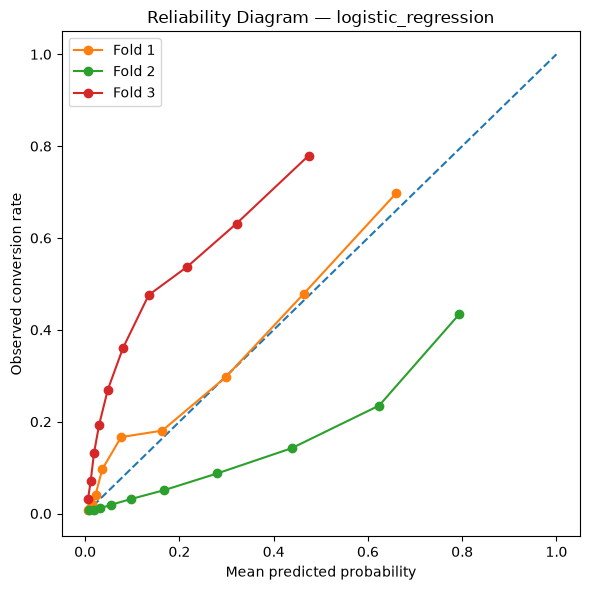

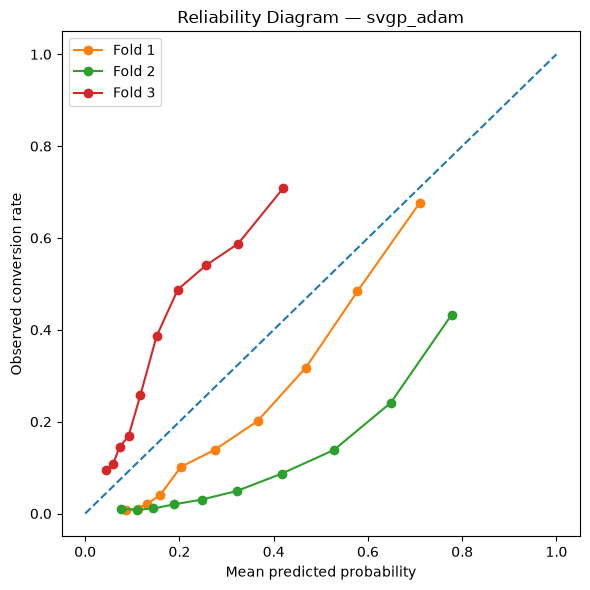

,model,fold,calibration_rows,evaluation_rows,q_hat,target_coverage,empirical_coverage,coverage_gap,absolute_coverage_gap,average_set_size,singleton_rate,both_labels_rate,empty_set_rate,positive_class_coverage,negative_class_coverage
0,logistic_regression,2,168945,140194,0.427475,0.8,0.780989,-0.019011,0.019011,0.923642,0.923642,0.0,0.076358,0.609477,0.800644
1,logistic_regression,3,309139,127706,0.442019,0.8,0.651199,-0.148801,0.148801,0.950707,0.950707,0.0,0.049293,0.030312,0.982928
2,svgp_adam,2,168945,140194,0.472517,0.8,0.755767,-0.044233,0.044233,0.952494,0.952494,0.0,0.047506,0.730748,0.758634
3,svgp_adam,3,309139,127706,0.494132,0.8,0.653493,-0.146507,0.146507,0.997980,0.997980,0.0,0.002020,0.007780,0.998486


In [8]:
for model_name in reliability["model"].unique():
    part = reliability[reliability["model"] == model_name]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], linestyle="--")

    for fold, fold_part in part.groupby("fold"):
        ax.plot(
            fold_part["mean_predicted_probability"],
            fold_part["observed_conversion_rate"],
            marker="o",
            label=f"Fold {fold}",
        )

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed conversion rate")
    ax.set_title(f"Reliability Diagram — {model_name}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        OUT / f"reliability_{model_name.lower().replace(' ', '_')}.png",
        dpi=180,
    )
    plt.show()

coverage.sort_values(["model", "fold"]).reset_index(drop=True)

## Interpretation Guide

- **Log Loss / Brier / PR-AUC / ROC-AUC**: overall probability quality and discrimination.
- **ECE + Reliability Diagram**: probabilistic calibration quality.
- **Calibration intercept / slope**: ideal values are near 0 and 1, respectively.
- **Probability bias**: mean predicted probability minus observed prevalence.
- **Empirical 80% prediction-set coverage**: check closeness to 0.80.
- **Set efficiency**: average set size, singleton rate, both-labels rate, and empty-set rate.
- **Class-conditional coverage**: compare positive vs negative class coverage.
- **Temporal robustness**: inspect fold-wise behavior, especially worst-fold coverage drop under temporal shift.